# Breast Cancer Detection Model using Machine Learning 


## Introduction
This project aims to build a machine learning model to classify breast cancer samples using gene expression data obtained from GEO (GSE183947 dataset).

## Dataset Description
The dataset is obtained from GEO and contains gene expression values in FPKM format for tumor and normal samples.

## Tools and Technologies Used

### Software and Development Environment
- Visual Studio Code (VS Code) – used as the primary development environment
- Jupyter Notebook – used for interactive coding and analysis

### Programming Language
- Python – used for data processing, analysis, and machine learning implementation

### Libraries
- pandas – for data manipulation and handling
- numpy – for numerical computations
- matplotlib – for data visualization
- scikit-learn – for machine learning algorithms and evaluation
- scipy – for scientific computations

## Objectives
- To preprocess gene expression data
- To perform feature selection
- To train machine learning models
- To evaluate model performance

## Workflow
1. Data Loading
2. Data Preprocessing
3. Feature Selection
4. Model Training
5. Model Evaluation

## (1.) Data Loading
In this step, the dataset is loaded using pandas and basic structure is examined.

In [2]:
import sys
!{sys.executable} -m pip install pandas numpy matplotlib scikit-learn scipy ipykernel


[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: C:\Users\Admin\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd 
df = pd.read_csv(r"C:\Users\Admin\Downloads\GSE183947_fpkm.csv.gz", compression='gzip')
df.head() 

,Unnamed: 0,CA.102548,CA.104338,CA.105094,CA.109745,CA.1906415,CA.1912627,CA.1924346,CA.1926760,CA.1927842,...,CAP.2040686,CAP.2046297,CAP.2046641,CAP.348981,CAP.354300,CAP.359448,CAP.94377,CAP.98389,CAP.98475,CAP.99145
0,TSPAN6,0.93,1.97,0.00,5.45,4.52,4.75,3.96,3.58,6.41,...,6.66,8.35,8.94,6.33,5.94,6.35,3.74,4.84,10.46,4.54
1,TNMD,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.23,0.39,...,0.12,0.17,1.08,0.29,0.00,0.07,9.19,1.18,0.09,0.39
2,DPM1,0.00,0.43,0.00,3.43,8.45,8.53,7.80,7.62,6.40,...,4.93,7.47,5.72,4.96,9.28,9.15,4.77,3.75,7.31,2.77
3,SCYL3,5.78,5.17,8.76,4.58,7.20,6.03,9.05,5.37,5.92,...,8.02,6.00,5.28,4.98,4.45,7.00,4.14,5.51,7.45,2.33
4,C1orf112,2.83,6.26,3.37,6.24,5.16,13.69,6.69,5.28,7.65,...,7.91,4.61,8.35,9.84,7.68,5.62,2.81,7.08,7.28,5.39


## (2.) Data Preprocessing 

In [4]:
# Check column names first (VERY IMPORTANT)
print(df.columns)

Index(['Unnamed: 0', 'CA.102548', 'CA.104338', 'CA.105094', 'CA.109745',
       'CA.1906415', 'CA.1912627', 'CA.1924346', 'CA.1926760', 'CA.1927842',
       'CA.1933414', 'CA.1940640', 'CA.2004407', 'CA.2005288', 'CA.2006047',
       'CA.2008260', 'CA.2009329', 'CA.2009381', 'CA.2009850', 'CA.2017611',
       'CA.2039179', 'CA.2040686', 'CA.2045012', 'CA.2046297', 'CA.348981',
       'CA.354300', 'CA.359448', 'CA.94377', 'CA.98389', 'CA.98475',
       'CA.99145', 'CAP.102548', 'CAP.104338', 'CAP.105094', 'CAP.109745',
       'CAP.1906415', 'CAP.1912627', 'CAP.1924346', 'CAP.1926760',
       'CAP.1927842', 'CAP.1933414', 'CAP.1940640', 'CAP.2004407',
       'CAP.2005288', 'CAP.2006047', 'CAP.2008260', 'CAP.2009329',
       'CAP.2009381', 'CAP.2009850', 'CAP.2017611', 'CAP.2039179',
       'CAP.2040686', 'CAP.2046297', 'CAP.2046641', 'CAP.348981', 'CAP.354300',
       'CAP.359448', 'CAP.94377', 'CAP.98389', 'CAP.98475', 'CAP.99145'],
      dtype='str')


### (1.) Data Transposition 

In [5]:
# Set first column as index (gene names)
df = df.set_index(df.columns[0])


# Transpose dataset (samples as rows, genes as columns)
df = df.T

# Check shape
print("Shape after transpose:", df.shape) 
df.head() 

Shape after transpose: (60, 20246)


Unnamed: 0,TSPAN6,TNMD,DPM1,SCYL3,C1orf112,FGR,CFH,FUCA2,GCLC,NFYA,...,CTB-96E2.2,CTC-432M15.3,RP11-986E7.7,RP11-761B3.1,ZBTB8B,RP11-1084J3.4,RP11-944L7.5,FLJ00388,RP11-474G23.1,AC005358.1
CA.102548,0.93,0.0,0.00,5.78,2.83,4.80,1.37,21.92,34.16,0.70,...,0.0,0.0,0.00,0.00,38.27,0.00,0.0,0.00,0.00,0.0
CA.104338,1.97,0.0,0.43,5.17,6.26,1.83,1.78,10.48,25.12,1.13,...,0.0,0.0,0.10,0.03,30.99,0.16,0.0,0.00,0.00,0.0
CA.105094,0.00,0.0,0.00,8.76,3.37,0.00,0.00,0.00,21.77,0.00,...,0.0,0.0,0.00,0.00,47.57,0.00,0.0,0.00,0.00,0.0
CA.109745,5.45,0.0,3.43,4.58,6.24,4.23,2.59,23.78,16.48,10.72,...,0.0,0.0,1.15,0.00,12.27,0.00,0.0,0.83,0.10,0.0
CA.1906415,4.52,0.0,8.45,7.20,5.16,15.87,9.21,14.95,18.19,17.50,...,0.0,0.0,0.00,0.00,4.69,0.00,0.0,0.00,0.64,0.0


### (2.) Handling Missing Values  

In [6]:
# Finding the missing values 
print(df.isnull().sum().sum()) 
# Filling with the median value 
df = df.fillna(df.median()) 

0


### (3.) Data Type Conversion 

In [7]:
df = df.apply(pd.to_numeric, errors="coerce") 
df.head() 

Unnamed: 0,TSPAN6,TNMD,DPM1,SCYL3,C1orf112,FGR,CFH,FUCA2,GCLC,NFYA,...,CTB-96E2.2,CTC-432M15.3,RP11-986E7.7,RP11-761B3.1,ZBTB8B,RP11-1084J3.4,RP11-944L7.5,FLJ00388,RP11-474G23.1,AC005358.1
CA.102548,0.93,0.0,0.00,5.78,2.83,4.80,1.37,21.92,34.16,0.70,...,0.0,0.0,0.00,0.00,38.27,0.00,0.0,0.00,0.00,0.0
CA.104338,1.97,0.0,0.43,5.17,6.26,1.83,1.78,10.48,25.12,1.13,...,0.0,0.0,0.10,0.03,30.99,0.16,0.0,0.00,0.00,0.0
CA.105094,0.00,0.0,0.00,8.76,3.37,0.00,0.00,0.00,21.77,0.00,...,0.0,0.0,0.00,0.00,47.57,0.00,0.0,0.00,0.00,0.0
CA.109745,5.45,0.0,3.43,4.58,6.24,4.23,2.59,23.78,16.48,10.72,...,0.0,0.0,1.15,0.00,12.27,0.00,0.0,0.83,0.10,0.0
CA.1906415,4.52,0.0,8.45,7.20,5.16,15.87,9.21,14.95,18.19,17.50,...,0.0,0.0,0.00,0.00,4.69,0.00,0.0,0.00,0.64,0.0


### (4.) Label Assignment 

In [8]:
# Create labels for classification
labels = ["tumor"] * 30 + ["normal"] * 30

# Add labels to dataset
df["label"] = labels

# Check distribution
print(df["label"].value_counts())

# Separate features (X) and target variable (y)
X = df.drop(columns=["label"])   # All gene expression values (features)
y = df["label"]                  # Target variable (tumor / normal) 

print("X shape:", X.shape)
print("y distribution:\n", y.value_counts()) 

label
tumor     30
normal    30
Name: count, dtype: int64
X shape: (60, 20246)
y distribution:
 label
tumor     30
normal    30
Name: count, dtype: int64


### (5.) Feature (X) Log Transformation + Feature Scaling on X only 

#### (1.) Log Transformation of the feature (X) 

In [9]:
import numpy as np

# Apply log base 2 transformation to reduce skewness in gene expression data
# Adding 1 avoids log(0), since log(0) is undefined
# This transformation stabilizes variance and improves model performance

X = np.log2(X + 1)

# Display first few rows to verify transformation
X.head() 

Unnamed: 0,TSPAN6,TNMD,DPM1,SCYL3,C1orf112,FGR,CFH,FUCA2,GCLC,NFYA,...,CTB-96E2.2,CTC-432M15.3,RP11-986E7.7,RP11-761B3.1,ZBTB8B,RP11-1084J3.4,RP11-944L7.5,FLJ00388,RP11-474G23.1,AC005358.1
CA.102548,0.948601,0.0,0.000000,2.761285,1.937344,2.536053,1.244887,4.518535,5.135863,0.765535,...,0.0,0.0,0.000000,0.000000,5.295356,0.000000,0.0,0.000000,0.000000,0.0
CA.104338,1.570463,0.0,0.516015,2.625270,2.859970,1.500802,1.475085,3.521051,4.707083,1.090853,...,0.0,0.0,0.137504,0.042644,4.999549,0.214125,0.0,0.000000,0.000000,0.0
CA.105094,0.000000,0.0,0.000000,3.286881,2.127633,0.000000,0.000000,0.000000,4.509062,0.000000,...,0.0,0.0,0.000000,0.000000,5.601994,0.000000,0.0,0.000000,0.000000,0.0
CA.109745,2.689299,0.0,2.147307,2.480265,2.855990,2.386811,1.843984,4.631104,4.127633,3.550901,...,0.0,0.0,1.104337,0.000000,3.730096,0.000000,0.0,0.871844,0.137504,0.0
CA.1906415,2.464668,0.0,3.240314,3.035624,2.622930,4.076388,3.351911,3.995485,4.262283,4.209453,...,0.0,0.0,0.000000,0.000000,2.508429,0.000000,0.0,0.000000,0.713696,0.0


#### (2.) Feature (X) Scaling 

In [10]:
# Feature Scaling in the dataset 
from sklearn.preprocessing import StandardScaler

# Initialize scaler
scaler = StandardScaler()

# Apply scaling (mean = 0, std = 1)
X_scaled = scaler.fit_transform(X)

# Convert back to DataFrame
X_scaled = pd.DataFrame(X_scaled, columns=X.columns, index=X.index)

# Check transformed data
X_scaled.head()

Unnamed: 0,TSPAN6,TNMD,DPM1,SCYL3,C1orf112,FGR,CFH,FUCA2,GCLC,NFYA,...,CTB-96E2.2,CTC-432M15.3,RP11-986E7.7,RP11-761B3.1,ZBTB8B,RP11-1084J3.4,RP11-944L7.5,FLJ00388,RP11-474G23.1,AC005358.1
CA.102548,-2.315255,-0.644245,-2.281513,-0.076274,-1.616902,-0.388598,-1.901008,0.831622,0.966528,-2.460826,...,-0.222775,-0.462402,-0.947778,-0.298033,2.538072,-0.74488,0.0,-0.314491,-0.968980,-0.506998
CA.104338,-1.550507,-0.644245,-1.817638,-0.303545,-0.346303,-1.377888,-1.697795,-0.203919,0.396007,-2.184055,...,-0.222775,-0.462402,-0.704373,-0.093070,2.236601,-0.10276,0.0,-0.314491,-0.968980,-0.506998
CA.105094,-3.481816,-0.644245,-2.281513,0.801963,-1.354844,-2.812060,-2.999961,-3.859306,0.132528,-3.112121,...,-0.222775,-0.462402,-0.947778,-0.298033,2.850582,-0.74488,0.0,-0.314491,-0.968980,-0.506998
CA.109745,-0.174594,-0.644245,-0.351177,-0.545840,-0.351783,-0.531214,-1.372141,0.948486,-0.374988,-0.091118,...,-0.222775,-0.462402,1.007093,-0.298033,0.942841,-0.74488,0.0,1.598264,-0.557177,-0.506998
CA.1906415,-0.450839,-0.644245,0.631389,0.382128,-0.672743,1.083352,-0.040983,0.288616,-0.195828,0.469159,...,-0.222775,-0.462402,-0.947778,-0.298033,-0.302220,-0.74488,0.0,-0.314491,1.168432,-0.506998


## (6.) Train-Test Split 

In [11]:
from sklearn.model_selection import train_test_split

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,      # 20% data for testing
    random_state=42,    # ensures reproducibility
    stratify=y          # keeps class balance (important!)
)

# Check shapes
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:\n", y_train.value_counts())
print("y_test:\n", y_test.value_counts())

X_train: (48, 20246)
X_test: (12, 20246)
y_train:
 label
tumor     24
normal    24
Name: count, dtype: int64
y_test:
 label
normal    6
tumor     6
Name: count, dtype: int64


## (7.) Feature Selection using SelectKBest 

In [12]:
# Import SelectKBest (Statistical Method) 
from sklearn.feature_selection import SelectKBest, f_classif

# Select top 100 most important genes
selector = SelectKBest(score_func=f_classif, k=100)

# Fit only on training data (IMPORTANT)
X_train_selected = selector.fit_transform(X_train, y_train)

# Apply same transformation to test data
X_test_selected = selector.transform(X_test)

# Check new shape
print("Before selection:", X_train.shape)
print("After selection:", X_train_selected.shape) 

C:\Users\Admin\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:110: UserWarning: Features [ 1061  2105  5141  5383 10084 12578 12580 12615 13150 13169 14880 15182
 15198 15656 15827 15889 15903 15925 16133 16342 16794 16836 16899 17386
 17622 17855 17873 17880 18102 18142 18153 18169 18182 18183 18206 18208
 18209 18261 18271 18284 18301 18461 18470 18476 18479 18508 18509 18524
 18555 18558 18560 18612 18639 18648 18650 18722 18742 18797 18815 18840
 18843 18852 18896 18977 18993 19051 19063 19134 19145 19273 19407 19451
 19457 19533 19571 19585 19825 19826 19839 19846 19847 19858 19864 19867
 19871 19873 19875 19878 19889 19893 19895 19899 19900 19901 19903 19908
 19912 19919 19925 19928 19935 19945 19948 19951 19956 19958 19959 19966
 19968 19972 19975 19976 19977 19981 19987 19991 19997 20004 20007 20008
 20009 20025 20029 20032 20033 20037 20040 20047 20054 20057 20071 20076
 20078 20083 20086 20091 20094 20095 20099 201

Before selection: (48, 20246)
After selection: (48, 100)


## (8.) The Model Building Using SVM 

In [13]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Initialize the SVM model
svm_model = SVC(kernel='linear', random_state=42)

# Train the model using selected features
svm_model.fit(X_train_selected, y_train)

# Predict on test data
y_pred = svm_model.predict(X_test_selected)

# Model evaluation
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 1.0

Confusion Matrix:
 [[6 0]
 [0 6]]

Classification Report:
               precision    recall  f1-score   support

      normal       1.00      1.00      1.00         6
       tumor       1.00      1.00      1.00         6

    accuracy                           1.00        12
   macro avg       1.00      1.00      1.00        12
weighted avg       1.00      1.00      1.00        12



## (9.) Final Results, Confusion Matrix Visualization, And Model Evaluation 

Final Accuracy: 1.0

Confusion Matrix:
 [[6 0]
 [0 6]]


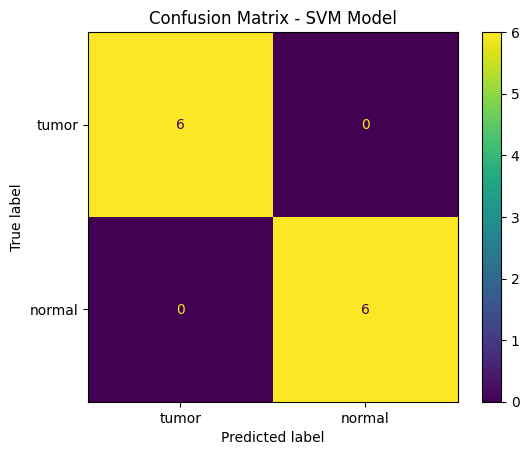


Classification Report:
               precision    recall  f1-score   support

      normal       1.00      1.00      1.00         6
       tumor       1.00      1.00      1.00         6

    accuracy                           1.00        12
   macro avg       1.00      1.00      1.00        12
weighted avg       1.00      1.00      1.00        12



In [14]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, classification_report

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Final Accuracy:", accuracy)

# Confusion Matrixcd ~/Desktop/Machine_Learning_Project
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)

# Plot Confusion Matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["tumor", "normal"])
disp.plot()
plt.title("Confusion Matrix - SVM Model")
plt.show()

# Classification Report
print("\nClassification Report:\n", classification_report(y_test, y_pred))

## (10.) Cross- Validation 

In [15]:
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import cross_val_score
from sklearn.svm import SVC

pipeline = Pipeline([
    ('feature_selection', SelectKBest(f_classif, k=100)),
    ('classifier', SVC(kernel='linear'))
])

scores = cross_val_score(pipeline, X_scaled, y, cv=5)

print("CV Accuracy:", scores)
print("Mean:", scores.mean())

C:\Users\Admin\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:110: UserWarning: Features [ 1061  2105  5141  5383 10084 12578 12580 12615 13150 13169 14880 15182
 15198 15656 15827 15889 15903 15925 16133 16342 16794 16836 16899 17386
 17622 17855 17873 17880 18102 18142 18153 18169 18182 18183 18206 18208
 18209 18261 18271 18284 18301 18461 18470 18476 18479 18508 18509 18524
 18555 18558 18560 18612 18639 18648 18650 18722 18742 18797 18815 18840
 18843 18852 18896 18977 18993 19051 19063 19134 19145 19273 19407 19451
 19457 19533 19571 19585 19825 19826 19839 19846 19847 19858 19864 19867
 19871 19873 19875 19878 19889 19893 19895 19899 19900 19901 19903 19908
 19912 19919 19925 19928 19935 19945 19948 19951 19956 19958 19959 19966
 19968 19972 19975 19976 19977 19981 19987 19991 19997 20004 20007 20008
 20009 20025 20029 20032 20033 20037 20040 20047 20054 20057 20071 20076
 20078 20083 20086 20091 20094 20095 20099 201

CV Accuracy: [1. 1. 1. 1. 1.]
Mean: 1.0


## (11.) ROC Curve 

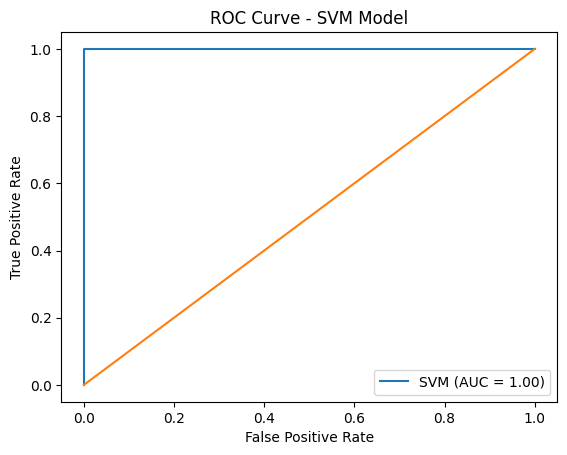

In [16]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt 

# Get prediction scores
y_scores = svm_model.decision_function(X_test_selected) 

# Convert labels to binary 
y_test_binary = (y_test == "tumor").astype(int) 

# Computed ROC curve
fpr, tpr, thresholds = roc_curve(y_test_binary, y_scores)
roc_auc = auc(fpr, tpr) 

# Plot ROC 
plt.figure()
plt.plot(fpr, tpr, label="SVM (AUC = %0.2f)" % roc_auc)
plt.plot([0, 1], [0, 1])  # diagonal line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - SVM Model") 
plt.legend(loc="lower right") 
plt.show() 

## (12.) PCA Visualization 

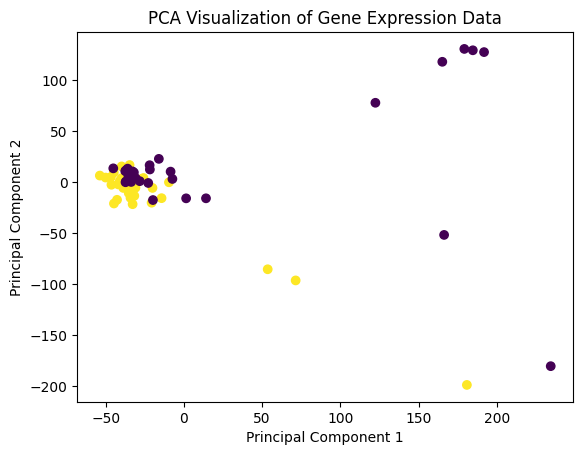

In [17]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt 

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled) 

# Convert labels to colors
colors = (y == "tumor").astype(int) 

# Plot PCA
plt.figure()
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=colors)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Visualization of Gene Expression Data")
plt.show() 

## (13.) Conclusion 
In this project, a machine learning-based approach is developed to classify breast cancer samples using high-dimensional gene expression data. The integration of preprocessing, feature selection, and SVM classification resulted in excellent performance, with perfect accuracy and AUC scores. PCA visualization further supported the clear separation between tumor and normal samples. 

Despite these promising results, the small sample size and large feature space may lead to overfitting. Future work should focus on validating the model across independent datasets and exploring advanced techniques to improve generalizability and biological interpretability. 